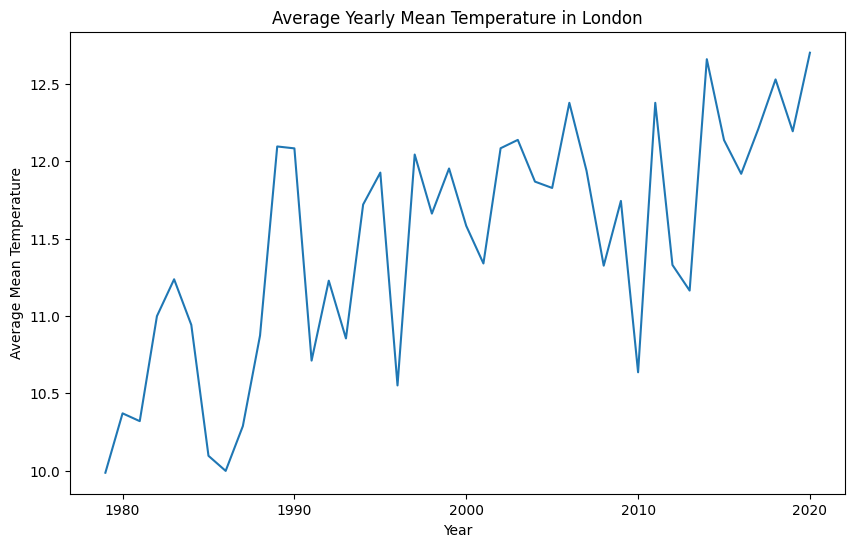

Linear Regression RMSE : 0.8733424980671911 
Decision Tree (Depth 5) RMSE : 1.2616091843051462 
Decision Tree (Depth 10) RMSE : 1.0195782023702142 
Random Forest (100 trees) RMSE : 0.8518327152938082 


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.rmse,tags.mlflow.runName,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.user
0,14ff7d55632b443ab915d320713e6ce5,0,FINISHED,/media/samrat01/WD_BLACK/M_Documents/DataCamp_...,2026-05-25 10:46:51.079000+00:00,2026-05-25 10:46:55.365000+00:00,0.851833,defiant-rook-229,NOTEBOOK,temp.pred.ipynb,samrat01
1,04cfb03ea43440d9b05af3115d06908a,0,FINISHED,/media/samrat01/WD_BLACK/M_Documents/DataCamp_...,2026-05-25 10:46:51.025000+00:00,2026-05-25 10:46:51.074000+00:00,1.019578,skillful-dolphin-317,NOTEBOOK,temp.pred.ipynb,samrat01
2,1c41241e16a84418b9307a7ce6470a85,0,FINISHED,/media/samrat01/WD_BLACK/M_Documents/DataCamp_...,2026-05-25 10:46:50.985000+00:00,2026-05-25 10:46:51.018000+00:00,1.261609,amazing-shark-185,NOTEBOOK,temp.pred.ipynb,samrat01
3,d0f5f60f8e5c4ab29ee3a53011ed8fff,0,FINISHED,/media/samrat01/WD_BLACK/M_Documents/DataCamp_...,2026-05-25 10:46:50.960000+00:00,2026-05-25 10:46:50.980000+00:00,0.873342,nervous-horse-163,NOTEBOOK,temp.pred.ipynb,samrat01
4,799313607b654305b9836ff646a02db6,0,FAILED,/media/samrat01/WD_BLACK/M_Documents/DataCamp_...,2026-05-25 10:46:19.070000+00:00,2026-05-25 10:46:19.088000+00:00,NaN,brawny-bass-875,NOTEBOOK,temp.pred.ipynb,samrat01


In [2]:
# Run this cell to import the modules you require
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Read in the data
weather = pd.read_csv("london_weather.csv")

# Start coding here
weather["date"] = pd.to_datetime(weather['date'].astype(str) , format='%Y%m%d' , errors= 'coerce')

weather['month'] = weather['date'].dt.month
weather['year'] = weather['date'].dt.year

# ploting and EDA
yearly_mean_temp = weather.groupby('year')['mean_temp'].mean()
plt.figure(figsize=(10,6))
plt.plot(yearly_mean_temp.index,yearly_mean_temp.values)
plt.xlabel("Year")
plt.ylabel("Average Mean Temperature")
plt.title("Average Yearly Mean Temperature in London")
plt.show()

# feature selection
weather = weather.dropna(subset=['mean_temp'])
X=weather.drop(columns=['mean_temp','date','pressure'])
y= weather['mean_temp']

correlation_data = X.corrwith(y)
correlation_data.sort_values(ascending=False)

# spliting and pipelining
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
preprocessor = Pipeline(steps=[
     ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
 ])

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

model_to_try = {
    "Linear Regression" : LinearRegression(),
    "Decision Tree (Depth 5)" : DecisionTreeRegressor(max_depth=5),
    "Decision Tree (Depth 10)" : DecisionTreeRegressor(max_depth=10),
    "Random Forest (100 trees)" : RandomForestRegressor(n_estimators=100, random_state=42)
}

for model_name, model in model_to_try.items():
    with mlflow.start_run():
        model.fit(X_train_preprocessed,y_train)
        y_pred = model.predict(X_test_preprocessed)
        rmse = root_mean_squared_error(y_test, y_pred)
        mlflow.log_metric("rmse", rmse)
        print(f"{model_name} RMSE : {rmse} ")


experiment_results = mlflow.search_runs()
experiment_results

# Use as many cells as you like